In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from sauce.experiv3 import BigramModel

model = BigramModel()

In [3]:
import torch
with open('../data/langv3.txt', 'r', encoding = 'utf-8') as f:
    text = f.read()

torch.manual_seed(1337)


tokens = []
for line in text.splitlines():
    tokens.append("<BOS>")
    tokens.extend(line.split())
    tokens.append("<EOS>")

chars = sorted(list(set(tokens)))
vocab_size = len(chars)
stoi = {w:i for i, w in enumerate(chars)}
itos = {i:w for i, w in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s.split()]
decode = lambda l: ' '.join([itos[i] for i in l])

data = torch.tensor(
    [stoi[t] for t in tokens],
    dtype=torch.long
)

In [3]:
len(tokens) / 1e+6

1.890365

In [4]:

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


def nearest_neighbors(word, model, k=10):
    emb = model.token_embedding.weight.detach().cpu().numpy()
    sim = cosine_similarity(emb)

    idx = stoi[word]

    neighbors = sim[idx].argsort()[::-1][1:k+1]

    return [(itos[i], sim[idx, i]) for i in neighbors]

In [4]:
ckpt = torch.load("../checkpoints/langv3/ckpt_5000.pt")
model.load_state_dict(ckpt['model_state_dict'])

<All keys matched successfully>

In [6]:
nearest_neighbors("obama", model, k=10)

[('icarusra', np.float32(0.22066633)),
 ('moro', np.float32(0.19515267)),
 ('vomi', np.float32(0.19017291)),
 ('icarus', np.float32(0.17263977)),
 ('jojora', np.float32(0.1531438)),
 ('jaku', np.float32(0.14953604)),
 ('jojoli', np.float32(0.14457051)),
 ('chichi', np.float32(0.14405079)),
 ('davili', np.float32(0.14173903)),
 ('yumyumra', np.float32(0.12893124))]

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [8]:
sentence = 'ta kema chichin soros ta vaku doro'
ids = encode(sentence)

x = torch.tensor(
    [ids],
    dtype = torch.long,
    device=device
)

In [9]:
model.to(device)
model.eval()
with torch.no_grad():
    model(x)

In [10]:
import matplotlib.pyplot as plt
import numpy as np

pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
pass
pass


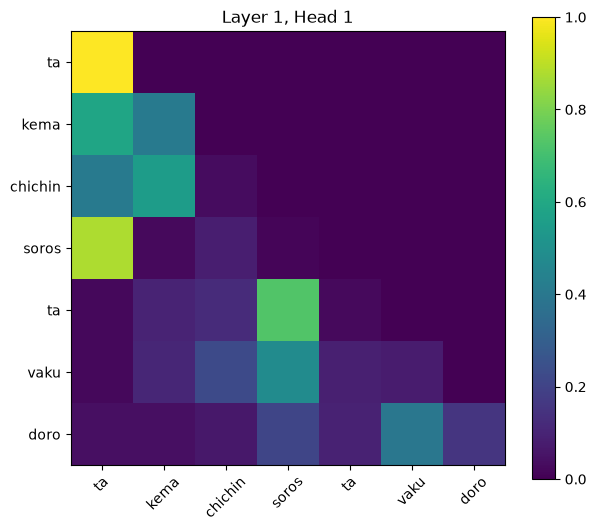

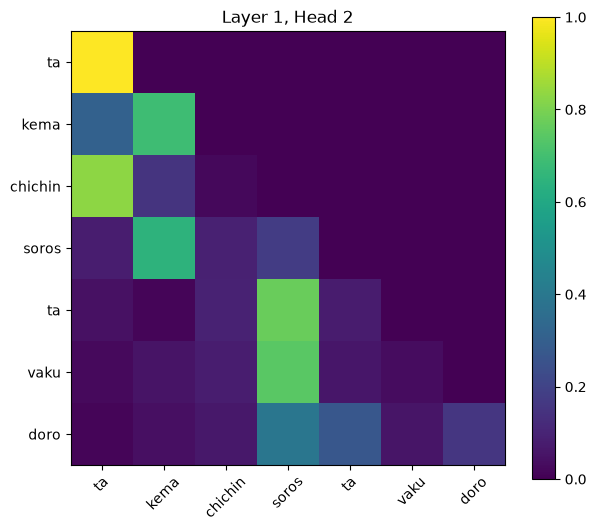

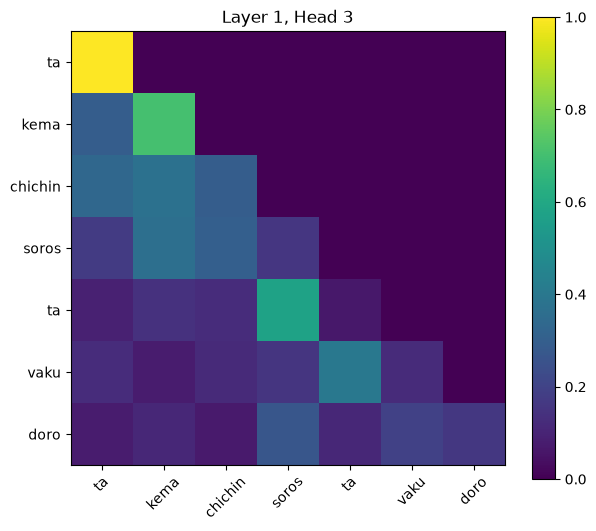

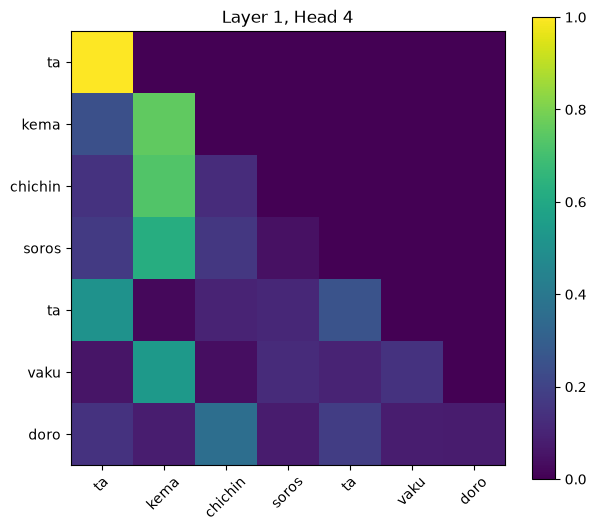

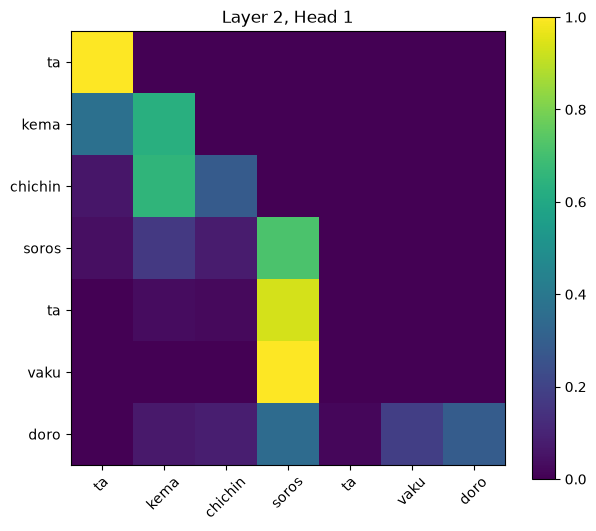

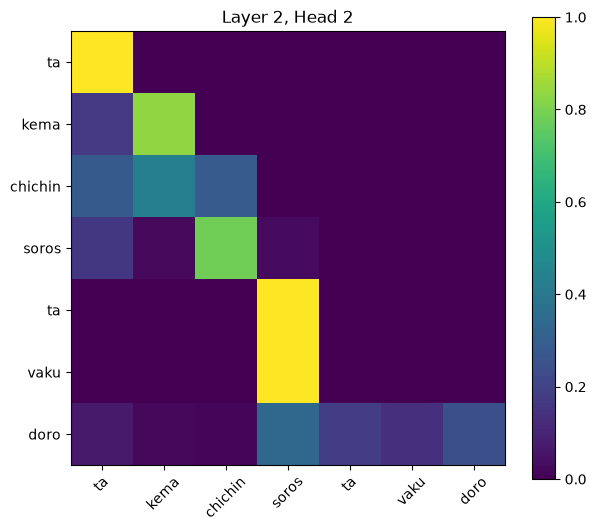

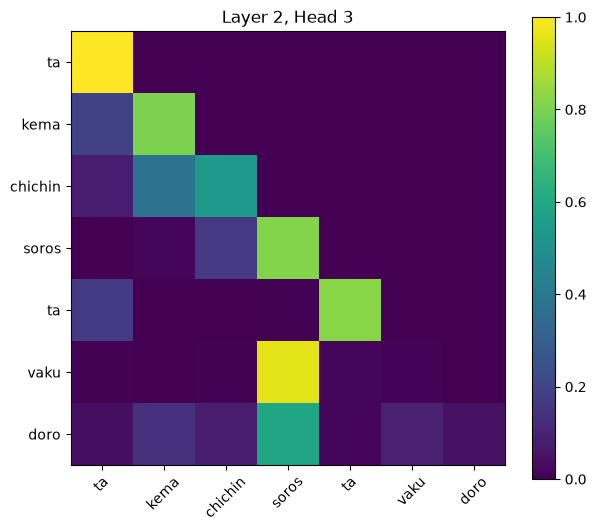

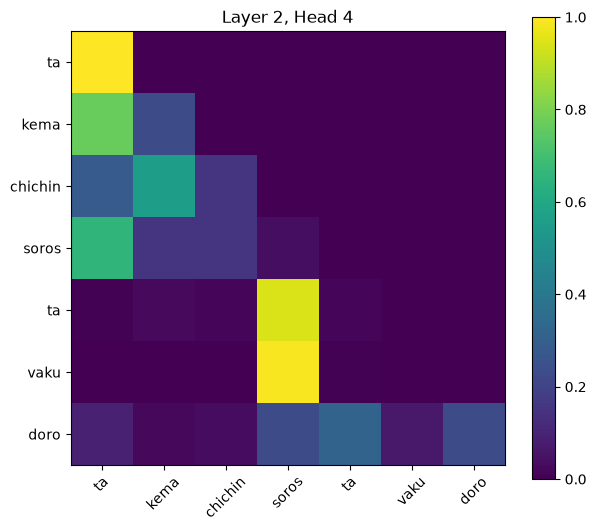

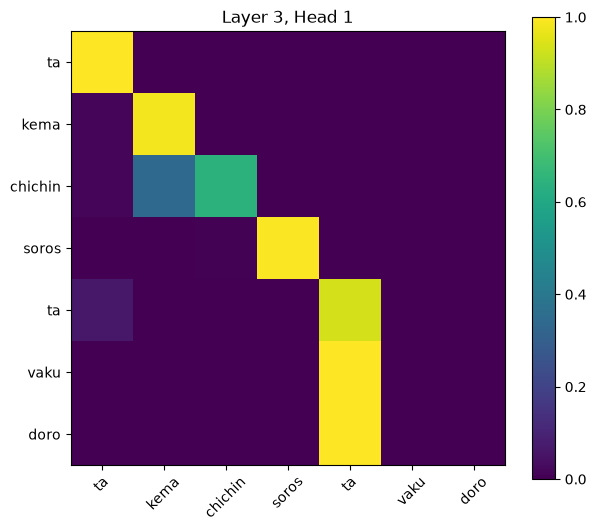

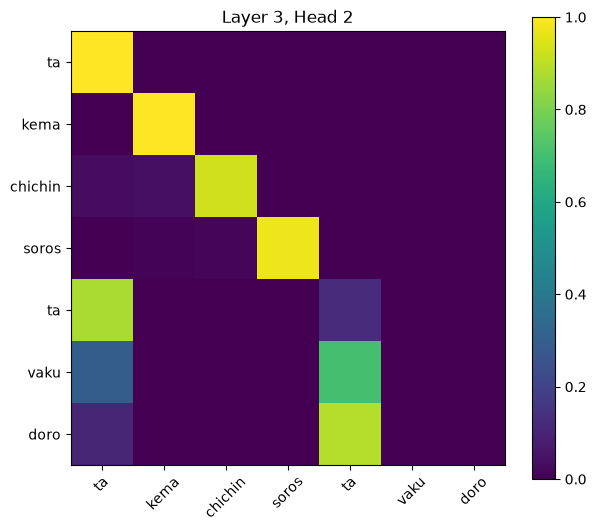

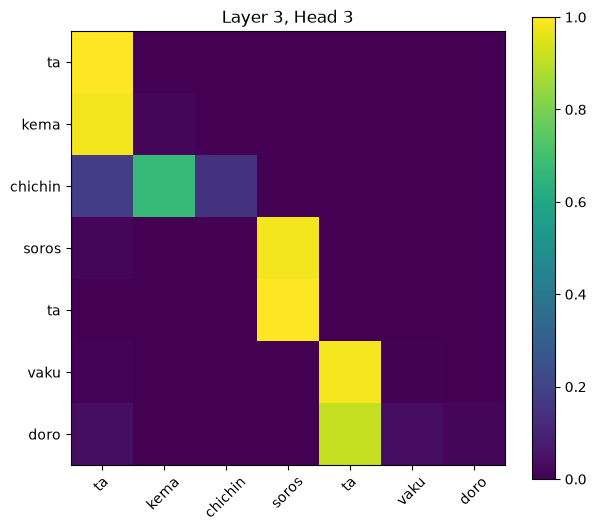

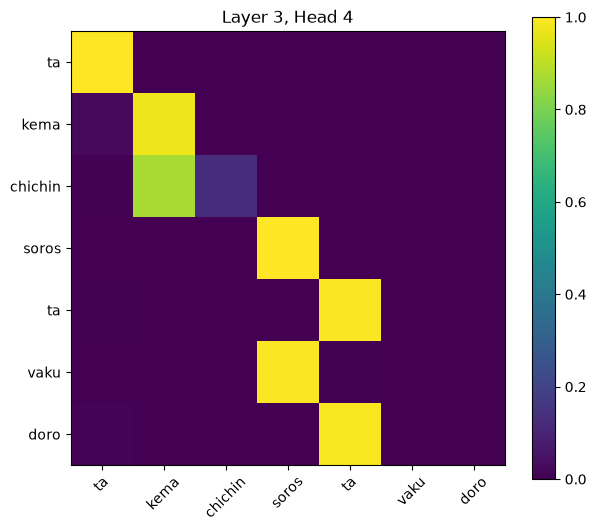

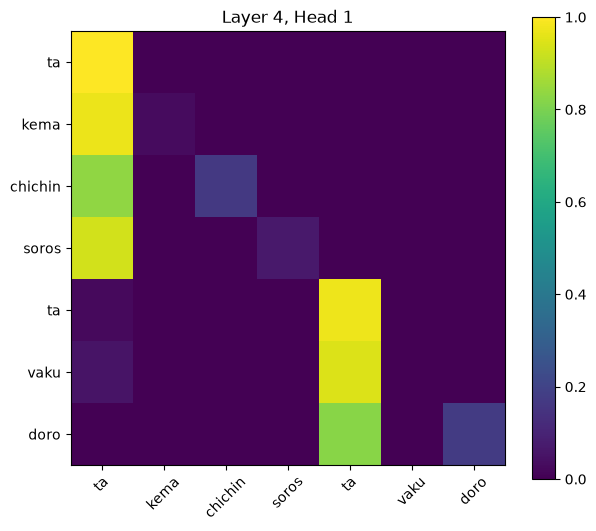

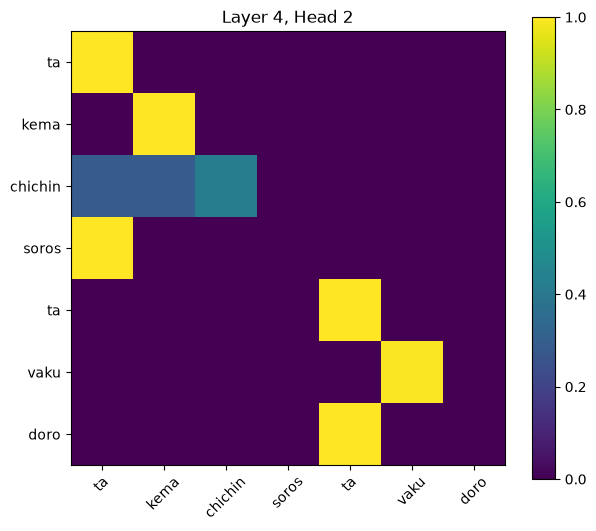

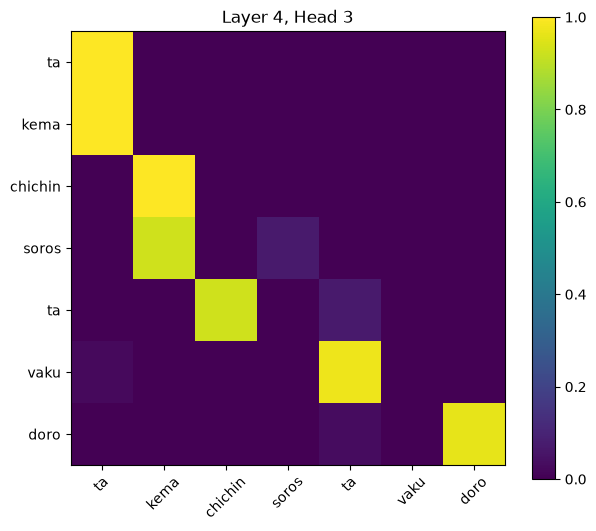

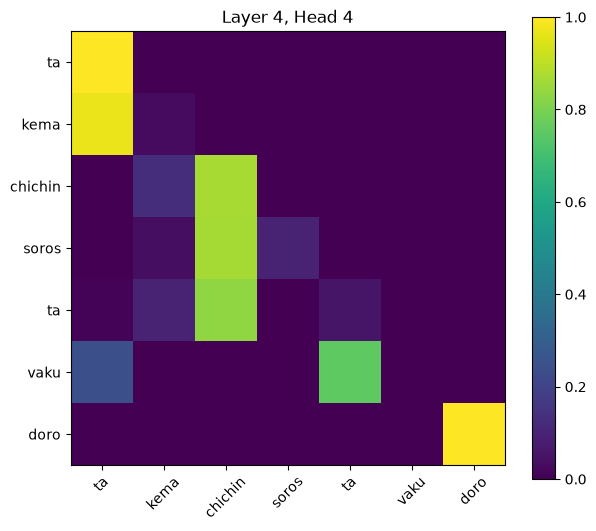

In [11]:
tokens = sentence.split()
for layer_idx, block in enumerate(model.blocks):
    for head_idx, head in enumerate(block.sa_head.heads):
        attn = head.last_attention[0].numpy()
        plt.figure(figsize=(7,6))
        plt.imshow(attn)
        plt.xticks(
            range(len(tokens)),
            tokens,
            rotation=45
        )
        plt.yticks(
            range(len(tokens)),
            tokens
        )
        plt.colorbar()

        plt.title(
            f"Layer {layer_idx+1}, Head {head_idx+1}"
        )
        plt.savefig(f'../plots/v3-chichin-doro-{layer_idx+1}-{head_idx+1}.png')
        print('pass')
        

In [12]:
device = 'cuda'
model.to(device)
context = torch.tensor(
    encode("ta"),
    device=device
).unsqueeze(0)

out = model.generate(
    context,
    max_new_tokens=20
)

sentence = decode(out[0].tolist())
sentence

'ta yera osaman lotilis ta moro mepa'

In [13]:
sentences = []
det = np.random.choice(['ta', 'na'])

for _ in range(500):
    context = torch.tensor(
    encode(det),
    device=device
    ).unsqueeze(0)

    out = model.generate(
        context,
        max_new_tokens=20
    )
    sentence = decode(out[0].tolist())
    sentences.append(sentence)
    


In [18]:
sentences

['ta henu doro',
 'ta vaku doro',
 'ta roni padre yumyum ta fira sopa',
 'ta pira pati',
 'ta tenu pati',
 'ta boku pati',
 'ta zeli kaka perv perv nexoras',
 'ta kema osama sisy ta sena sopa',
 'ta tenu mira',
 'ta bora mira',
 'ta zeli kaka ke na desa madren pervs pervra ta leni neko',
 'ta yera padre bobder na nemo doro',
 'ta leni padre ke na zeli chichi perv perv davira',
 'ta leni kakan jojolis',
 'ta pira sopa',
 'ta vaku madre loti ta fira mepa',
 'ta fomi padre bobder ta bora bexa',
 'ta sena ghar',
 'ta leni kakan yumyums ta sena mira',
 'ta vaku pati',
 'ta kema neko ke ta fomi obama perv davi',
 'ta loku obaman pakus ta jaku pati',
 'ta jaku doro',
 'ta boku tanu',
 'ta tenu kafka',
 'ta henu kafka',
 'ta leni padre soroli ta bora bexa',
 'ta zeli obama loti ta tenu kafka',
 'ta zeli madre yumyumli na nemo bren',
 'ta roni obaman yumyumlis na fira sopa',
 'ta sena tanu',
 'ta sena mepa',
 'ta desa padren ke na kema kaka perv pervs jojos',
 'ta fomi resta ke ta leni kawkawn 

In [14]:
animals = [
    "kuku",
    "neko",
    "resta",
    "kaka",
    "chichi",
    "kawkaw",
    "nori",
    "kukun",
    "nekon",
    "restan",
    "kakan",
    "chichin",
    "kawkawn",
    "norin",
]

objects = [
    "vomi",    # chair
    "kafka",   # book
    "ghar",    # house
    "doro",    # door
    "kito",    # window
    "mepa",    # map
    "pati",    # paper
    "bexa",    # box
    "vomi",
    "kafka",
    "mepa",
    "pati",
        "doro",
    "kito",
    "bexa",
    "kafka",
        "ghar",
    "doro",
    "kito",
    "bexa",
        "vomi",
    "kafka",
    "doro",
    "kito",
    "mepa",
    "pati",
    "bexa",

]

people = [
    "obama", "osama", "madre", "padre", "dumdum"
]

In [15]:
animals_fin = set(animals)
people_fin = set(people)
objects_fin = set(objects)


In [16]:
hidden_vectors = []
labels = []

for sentence in sentences:

    words = sentence.split()

    ids = torch.tensor(
        [encode(sentence)],
        device=device
    )

    with torch.no_grad():
        model(ids)

    hidden = model.last_hidden[0]

    for pos, word in enumerate(words):

        if word in people_fin:
            hidden_vectors.append(
                hidden[pos].numpy()
            )
            labels.append("human")

        elif word in animals_fin:
            hidden_vectors.append(
                hidden[pos].numpy()
            )
            labels.append("animal")

        elif word in objects_fin:
            hidden_vectors.append(
                hidden[pos].numpy()
            )
            labels.append("object")


In [17]:
len(labels)

538

In [18]:
import numpy as np
from sklearn.decomposition import PCA

X = np.array(hidden_vectors)
print(X.shape)


pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

(538, 128)


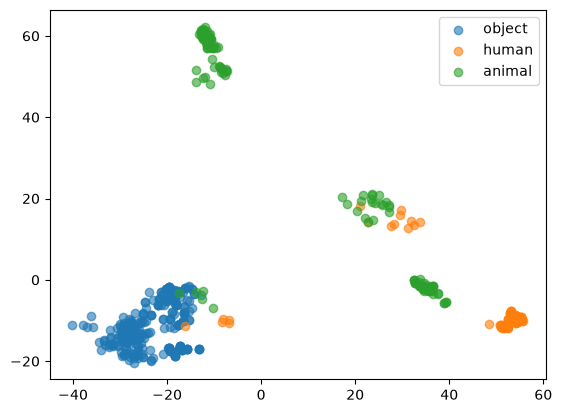

In [20]:
import matplotlib.pyplot as plt

for label in set(labels):

    idx = [
        i
        for i,l in enumerate(labels)
        if l == label
    ]

    plt.scatter(
        X_2d[idx,0],
        X_2d[idx,1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.savefig('../plots/v3hiddencluster')
plt.show()